# Verificacion de 2 bugs reales de LightCurveLynx / sncosmo, y la mejora medida al corregirlos

Este notebook sigue el mismo estilo que el [notebook oficial de LightCurveLynx sobre Rubin DP2](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/rubin_dp2.html) --carga cadencia real de observacion, arma un modelo SALT2/SIMSED real, simula curvas de luz cony sin ruido -- pero le agrega algo que ese notebook no hace: una comparacion cuantitativa contrauna referencia real independiente (`SNANA`, el motor de simulacion oficial que usa este proyectoen produccion) para demostrar, con datos reales de punta a punta, que **hubo un bug real** en`sncosmo`/`LightCurveLynx`, y que **corregirlo mejora el resultado de forma medible**.

Dos bugs, cada uno con evidencia de codigo real de ambos lados:

1. **`SALT2.INFO` real declara `MAG_OFFSET: 0.27`, y `sncosmo.SALT2Source` nunca lo lee**(Fase 37 de la investigacion -- ver `NOTES.md`). Cierra el residuo acromatico de SNIa/SALT2 de`-0.2646` a `+0.0054` mag.
2. **SNANA nunca usa la fase nativa `0` del archivo SIMSED como referencia temporal -- siempre larecalibra al pico bolometrico real de cada template, y LightCurveLynx no lo hacia** (Fase 56).Cierra el residuo cromatico de `SNIa-91bg` a `<=0.05` mag en las 6 bandas LSST.

Contexto completo, los otros 2 bugs confirmados (rango de longitud de onda, colision de nombre en`add_effect()`), y la brecha de sobre-deteccion que **sigue abierta** (Fase 59, no la cierra ningunode los 4): `exploration/lightcurvelynx/SINTESIS_hallazgos_y_brecha_abierta.md`.

**Datos usados:** cadencia real DDF de `baseline_v5.3.1_10yrs` (SIMLIB/OpSim de produccion de esteproyecto, no simulada), passbands LSST reales, y el `.DUMP` real de SNANA (motor de referencia,`snlc_sim.exe` 11.05p) para las mismas campanas que corren en NLHPC.


## 1. Setup -- cadencia real DDF + passbands (igual que el notebook oficial)

In [1]:
from __future__ import annotations

import sqlite3
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sncosmo

from lightcurvelynx.astro_utils.mag_flux import mag2flux
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import DistModFromRedshift, X0FromDistMod
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import compute_noise_free_lightcurves, simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
from lightcurvelynx.utils.extrapolate import LinearDecay, ZeroPadding

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, "/home/mvalenzuela/AUTOSIM")

from pipeline.simlib.formatobs import format_obs  # noqa: E402
from snana_params import (  # noqa: E402
    build_dndz_powerlaw2_cdf, make_dndz_sampler, make_bifurcated_normal_sampler,
    make_mwebv_ratio_scatter, read_salt2_info, filter_ddf_field_contamination,
    SizeAwareFunctionNode,
)
from compare_brightness import read_snana_dump  # noqa: E402

SNANA_HOME = Path("/home/mvalenzuela")
OPSIM_DB = SNANA_HOME / "AUTOSIM/data/opsim/baseline_v5.3.1_10yrs.db"
SALT2_LOCAL_DIR = HERE / "salt2_h17_local"
DATASIM_DIR = SNANA_HOME / "DATASIM_LSST_1/DDF/SIMDv8"
# Fase 55: copia local ya versionada de los 6 filtros LSST reales (mismo
# total_{u,g,r,i,z,y}.dat que descargaria PassbandGroup.from_preset("LSST")
# sin table_dir=, salvo "u" que aca ya viene truncado a 413.4nm real -- ver
# run_simsed_poc.py. Usar la copia local (en vez de dejar que LightCurveLynx
# descargue de github.com/lsst/throughputs en cada corrida) evita una
# escritura de red a ~/.cache/lightcurvelynx/passbands/ que fallo real y
# repetidamente por cupo de disco (incidente de Fase 65) y corrompio la
# ejecucion completa del notebook via jupyter/nbconvert.
LSST_PASSBAND_TABLE_DIR = HERE / "lsst_passbands_local"
PIXSIZE = 0.2

con = sqlite3.connect(str(OPSIM_DB))
df = pd.read_sql_query("SELECT * FROM observations", con)
df_ddf = df[df["target_name"].str.contains("ddf_", na=False)].reset_index(drop=True)
df_ddf["field"] = df_ddf["target_name"].str.extract(r"ddf_(\w+)")


def snana_noise_columns(df_ddf: pd.DataFrame) -> pd.DataFrame:
    snana = format_obs(df_ddf, pixsize=PIXSIZE)
    sig_psf_arcsec = df_ddf["seeingFwhmEff"].to_numpy() / (2 * np.sqrt(2 * np.log(2)))
    noise_area_arcsec2 = 4 * np.pi * sig_psf_arcsec ** 2
    out = df_ddf.copy()
    out["sky_bg_e"] = snana["SKYSIG"].to_numpy() ** 2
    out["psf_footprint"] = noise_area_arcsec2 / PIXSIZE ** 2
    out["zp"] = mag2flux(snana["ZPT"].to_numpy())
    return out


df_ddf = snana_noise_columns(df_ddf)
obs_table = OpSim(df_ddf, zp_err_mag=0.005)
passband_group = PassbandGroup.from_preset(preset="LSST", table_dir=str(LSST_PASSBAND_TABLE_DIR))
print(f"Cadencia DDF real: {len(df_ddf):,} observaciones, {df_ddf['field'].nunique()} campos "
      f"({sorted(df_ddf['field'].dropna().unique())})")
print(f"Rango temporal: MJD {obs_table['time'].min():.1f} - {obs_table['time'].max():.1f} "
      f"({(obs_table['time'].max()-obs_table['time'].min())/365.25:.1f} anios)")


Cadencia DDF real: 145,345 observaciones, 6 campos (['cosmos', 'ecdfs', 'edfs_a', 'edfs_b', 'elaiss1', 'xmm_lss'])
Rango temporal: MJD 61211.3 - 64860.4 (10.0 anios)


## 2. El bug -- `SALT2.INFO` real vs. lo que `sncosmo` realmente lee

El modelo SALT2 real que usa SNANA (`SALT2.WFIRST-H17`, Hounsell+2018) trae un archivo`SALT2.INFO` con parametros de calibracion. `sncosmo.SALT2Source` solo lee 4 archivos de esedirectorio (`salt2_template_0/1.dat`, `salt2_color_correction.dat`,`salt2_color_dispersion.dat` y los mapas de error) -- **`SALT2.INFO` nunca se abre**, confirmadoleyendo el codigo fuente real de `sncosmo==2.13.0`. Eso significa que la clave `MAG_OFFSET: 0.27`-- que SNANA aplica a **toda** magnitud del modelo (`genmag_SALT2.c:2257`,`magobs = ZP - 2.5*log10(flux) + MAG_OFFSET`) -- se pierde en silencio.

In [2]:
print(open(SALT2_LOCAL_DIR / "SALT2.INFO").read())


DOCUMENTATION:
    PURPOSE:  SALT2 model for simulations and light curve fitting
    REF:
    - AUTHOR: R., Hounsell (WFIRST-SN sims and forecasts)
      ADS:    https://ui.adsabs.harvard.edu/abs/2018ApJ...867...23H
      SUBREF: Sec 4, 2 paragraphs after Eq 12
    INTENT:   Nominal
    USAGE_KEY:  GENMODEL,     FITMODEL_NAME
    USAGE_CODE: snlc_sim.exe, snlc_fit.exe
    VALIDATE_SCIENCE: Simulated forecasts for WFIRST/NGRST
    NOTES:
    - extended to NIR by Steve Rodney
    - intended only sim forecast and classification
    - BEWARE use on real NIR data 
    VERSIONS:
    - DATE:  2017
      AUTHORS: R. Kessler, S. Rodney
DOCUMENTATION_END:

# ========================================

RESTLAMBDA_RANGE  2000. 23000

COLORLAW_VERSION: 1
COLORCOR_PARAMS: 2800 9500 4 -1.33154627 0.61225710 -0.12117791 0.00840832
COLOR_OFFSET:  0.0

MAG_OFFSET: 0.27
SEDFLUX_INTERP_OPT: 1  # 1=>linear,    2=>spline
ERRMAP_INTERP_OPT:  1  # 0=snake off;  1=>linear  2=>spline
ERRMAP_KCOR_OPT:    1  # 1/0 

In [3]:
salt2_info = read_salt2_info(SALT2_LOCAL_DIR)
mag_offset_real = salt2_info["MAG_OFFSET"]
print(f"MAG_OFFSET real declarado por SALT2.INFO: {mag_offset_real}")

import inspect
sig = inspect.signature(sncosmo.SALT2Source.__init__)
print(f"\nsncosmo.SALT2Source.__init__ firma real: {sig}")
print("-> no existe ningun parametro relacionado con SALT2.INFO/MAG_OFFSET.")


MAG_OFFSET real declarado por SALT2.INFO: 0.27

sncosmo.SALT2Source.__init__ firma real: (self, modeldir=None, m0file='salt2_template_0.dat', m1file='salt2_template_1.dat', clfile='salt2_color_correction.dat', cdfile='salt2_color_dispersion.dat', errscalefile='salt2_lc_dispersion_scaling.dat', lcrv00file='salt2_lc_relative_variance_0.dat', lcrv11file='salt2_lc_relative_variance_1.dat', lcrv01file='salt2_lc_relative_covariance_01.dat', name=None, version=None)
-> no existe ningun parametro relacionado con SALT2.INFO/MAG_OFFSET.


## 3. Armar la poblacion SNIa/SALT2 real (mismos parametros de produccion),
parametrizada por `mag_offset`

Reconstruye exactamente el modelo que corre en produccion (`run_snia_ddf_poc.py` /`compare_brightness_truth_salt2.py`): mismo `DNDZ`, mismo sampler bifurcado de `x1`/`c` (Fase 32),mismo `Omega_m=0.315` real de SNANA (Fase 34), misma dispersion `GENSIGMA_MWEBV_RATIO=0.16` real(Fase 10), misma ley de extincion MW `F99` real (Fase 24) -- todos los fixes de las Fases 22-36 yaaplicados. La UNICA diferencia entre las dos corridas de este notebook es `mag_offset`: `0.0`(el comportamiento real de `sncosmo` sin el fix) vs. `0.27` (el valor real de `SALT2.INFO`).

In [4]:
GENRANGE_REDSHIFT = (0.011, 1.2)
SALT2C = dict(peak=-0.054, sigma_lo=0.043, sigma_hi=0.101, lo=-0.3, hi=0.5)
SALT2X1 = dict(peak=0.973, sigma_lo=1.472, sigma_hi=0.222, lo=-3.0, hi=2.0)
ALPHA, BETA = 0.14, 3.1
SIGMA_INT = 0.090
DNDZ_SEGMENTS = [(2.5e-5, 1.5, 0.0, 1.0), (9.7e-5, -0.5, 1.0, 3.0)]
DDF_FIELD_EBV = {
    "cosmos": 0.0182, "ecdfs": 0.0084, "edfs_a": 0.0062,
    "edfs_b": 0.0152, "elaiss1": 0.0080, "xmm_lss": 0.0251,
}
MW_RV = 3.1
GENSIGMA_MWEBV_RATIO = 0.16
NGENTOT_LC = 2000  # mismo NGENTOT_LC real que la campana SNANA DDF (pipeline/models.yaml)
SEED_BASE = 20260812  # misma semilla base que run_snia_ddf_poc.py -- misma poblacion exacta

local_src = sncosmo.SALT2Source(modeldir=str(SALT2_LOCAL_DIR), name="salt2-h17-local")


def build_source(mag_offset: float, seed_base: int = SEED_BASE):
    z_grid, cdf = build_dndz_powerlaw2_cdf(
        segments=DNDZ_SEGMENTS, z_min=GENRANGE_REDSHIFT[0], z_max=GENRANGE_REDSHIFT[1],
    )
    redshift_func = SizeAwareFunctionNode(
        make_dndz_sampler(z_grid, cdf, seed=seed_base + 1), node_label="redshift"
    )
    c_func = SizeAwareFunctionNode(
        make_bifurcated_normal_sampler(**SALT2C, seed=seed_base + 2), node_label="c"
    )
    x1_func = SizeAwareFunctionNode(
        make_bifurcated_normal_sampler(**SALT2X1, seed=seed_base + 3), node_label="x1"
    )
    distmod_func = DistModFromRedshift(redshift_func, H0=70.0, Omega_m=0.315)
    # mag_offset=0.0 -> reproduce el bug real (sncosmo ignora SALT2.INFO).
    # mag_offset=0.27 -> el fix real (Fase 37).
    m_abs_func = NumpyRandomFunc(
        "normal", loc=-19.365 + mag_offset, scale=SIGMA_INT, seed=seed_base + 4
    )
    x0_func = X0FromDistMod(
        distmod=distmod_func, x1=x1_func, c=c_func, alpha=ALPHA, beta=BETA, m_abs=m_abs_func,
    )
    radec_sampler = ObsTableRADECSampler(obs_table, extra_cols=["field"], seed=seed_base + 5, radius=0.0)
    radec_sampler.setters["selected_table_index"].dependency.set_seed(seed_base + 5)
    t0_func = NumpyRandomFunc(
        "uniform", low=float(obs_table["time"].min()), high=float(obs_table["time"].max()),
        seed=seed_base + 6,
    )
    mwebv_scatter = make_mwebv_ratio_scatter(GENSIGMA_MWEBV_RATIO, seed=seed_base + 10)

    def _field_to_ebv(size=None, field=None, **_kwargs):
        arr = np.asarray(field)
        nominal = np.array([DDF_FIELD_EBV.get(f, 0.0) for f in arr.ravel()]).reshape(arr.shape)
        return mwebv_scatter(nominal)

    ebv_func = SizeAwareFunctionNode(_field_to_ebv, node_label="ebv", field=radec_sampler.field)
    mw_extinction = ExtinctionEffect(
        extinction_model="F99", ebv=ebv_func, r_v=MW_RV, frame="observer", backend="dust_extinction",
    )
    source = SncosmoWrapperModel(
        local_src, t0=t0_func, x0=x0_func, x1=x1_func, c=c_func,
        ra=radec_sampler.ra, dec=radec_sampler.dec, redshift=redshift_func,
        node_label="source", time_extrapolation=LinearDecay(50.0), wave_extrapolation=ZeroPadding(),
    )
    source.add_effect(mw_extinction)
    return source


def peakmag_r_noiseless(mag_offset: float, ngentot: int = NGENTOT_LC, seed_base: int = SEED_BASE):
    t0 = time.time()
    source = build_source(mag_offset, seed_base=seed_base)
    graph_state = source.sample_parameters(num_samples=ngentot, rng_info=np.random.default_rng(seed_base + 8))
    lc = compute_noise_free_lightcurves(
        source, graph_state, passband_group,
        rest_frame_phase_min=0.0, rest_frame_phase_max=0.5, rest_frame_phase_step=1.0,
    )
    MAG_AB_ZP_NJY = 8.9 + 2.5 * 9
    rows = []
    for _, row in lc.iterrows():
        sub = row["lightcurve"]
        if sub is None or len(sub) == 0 or "r" not in sub.columns:
            continue
        peak_flux_true = sub["r"].to_numpy()[0]
        if peak_flux_true <= 0:
            continue
        rows.append({
            "SNID": str(int(row["id"])), "z": row["z"],
            "PEAKMAG_r_true": MAG_AB_ZP_NJY - 2.5 * np.log10(peak_flux_true),
        })
    print(f"  [mag_offset={mag_offset}] {len(rows)}/{ngentot} objetos, {time.time()-t0:.1f}s")
    return pd.DataFrame(rows)


## 4. Correr las dos poblaciones: `mag_offset=0.0` (bug) vs. `mag_offset=0.27` (fix real)

In [5]:
print("Simulando poblacion CON el bug (mag_offset=0.0, comportamiento real de sncosmo)...")
pop_bug = peakmag_r_noiseless(mag_offset=0.0)

print("\nSimulando poblacion CON el fix (mag_offset=0.27, valor real de SALT2.INFO)...")
pop_fix = peakmag_r_noiseless(mag_offset=mag_offset_real)


Simulando poblacion CON el bug (mag_offset=0.0, comportamiento real de sncosmo)...


  [mag_offset=0.0] 2000/2000 objetos, 28.9s

Simulando poblacion CON el fix (mag_offset=0.27, valor real de SALT2.INFO)...


  [mag_offset=0.27] 2000/2000 objetos, 29.1s


## 5. Comparar contra el `.DUMP` real de SNANA (`PEAKMAG_r`)

Referencia real: `SNIa_DDF_baseline_v5.3.1_10yrs.DUMP`, la salida real de `snlc_sim.exe` (SNANA11.05p) para la misma campana. Se aplica el filtro de contaminacion de campo real (Fase 33/36/48-- ~15% del `.DUMP` de referencia son objetos `GW_case_*`/`neutrino_*` del OpSim que no son SNIaDDF reales) antes de comparar.

In [6]:
dump_path = DATASIM_DIR / "SNIa_DDF_baseline_v5.3.1_10yrs" / "SNIa_DDF_baseline_v5.3.1_10yrs.DUMP"
snana = read_snana_dump(str(dump_path))
n_before = len(snana)
snana = filter_ddf_field_contamination(snana, str(OPSIM_DB), max_sep_deg=2.0)
print(f"Filtro de contaminacion de campo (Fase 33/36/48): {n_before - len(snana)}/{n_before} "
      f"objetos removidos ({100*(n_before-len(snana))/n_before:.1f}%)")

z_s = snana["ZHELIO"].to_numpy()
mag_s = snana["PEAKMAG_r"].to_numpy()
valid_s = (mag_s > -8) & (mag_s < 90) & np.isfinite(mag_s)
z_s, mag_s = z_s[valid_s], mag_s[valid_s]
print(f"SNANA real: {len(mag_s)} objetos con PEAKMAG_r valido, mediana={np.median(mag_s):.3f}")


def binned_delta(pop, z_min=GENRANGE_REDSHIFT[0], z_max=GENRANGE_REDSHIFT[1], nbins=7):
    bins = np.linspace(z_min, z_max, nbins + 1)
    z_l, mag_l = pop["z"].to_numpy(), pop["PEAKMAG_r_true"].to_numpy()
    rows = []
    for i in range(nbins):
        lo, hi = bins[i], bins[i + 1]
        ms, ml = (z_s >= lo) & (z_s < hi), (z_l >= lo) & (z_l < hi)
        ns, nl = ms.sum(), ml.sum()
        meds = np.median(mag_s[ms]) if ns else np.nan
        medl = np.median(mag_l[ml]) if nl else np.nan
        rows.append({"z_lo": lo, "z_hi": hi, "N_snana": ns, "med_snana": meds,
                     "N_lcl": nl, "med_lcl": medl, "delta": medl - meds})
    return pd.DataFrame(rows)


tab_bug = binned_delta(pop_bug)
tab_fix = binned_delta(pop_fix)
print("\n=== CON el bug (mag_offset=0.0) ===")
print(tab_bug.round(3).to_string(index=False))
print(f"delta medio bins 2-7: {tab_bug['delta'].iloc[1:].mean():+.4f} mag")
print("\n=== CON el fix (mag_offset=0.27, real) ===")
print(tab_fix.round(3).to_string(index=False))
print(f"delta medio bins 2-7: {tab_fix['delta'].iloc[1:].mean():+.4f} mag")


Filtro de contaminacion de campo (Fase 33/36/48): 304/2000 objetos removidos (15.2%)
SNANA real: 1534 objetos con PEAKMAG_r valido, mediana=24.631

=== CON el bug (mag_offset=0.0) ===
 z_lo  z_hi  N_snana  med_snana  N_lcl  med_lcl  delta
0.011 0.181        9     19.544     13   19.589  0.045
0.181 0.351       54     21.386     56   21.215 -0.171
0.351 0.521      149     22.393    158   22.031 -0.361
0.521 0.690      226     23.247    279   22.940 -0.307
0.690 0.860      318     24.257    386   23.926 -0.332
0.860 1.030      447     25.138    554   24.927 -0.211
1.030 1.200      331     26.028    554   25.932 -0.096
delta medio bins 2-7: -0.2463 mag

=== CON el fix (mag_offset=0.27, real) ===
 z_lo  z_hi  N_snana  med_snana  N_lcl  med_lcl  delta
0.011 0.181        9     19.544     13   19.859  0.315
0.181 0.351       54     21.386     56   21.485  0.099
0.351 0.521      149     22.393    158   22.301 -0.091
0.521 0.690      226     23.247    279   23.210 -0.037
0.690 0.860      318   

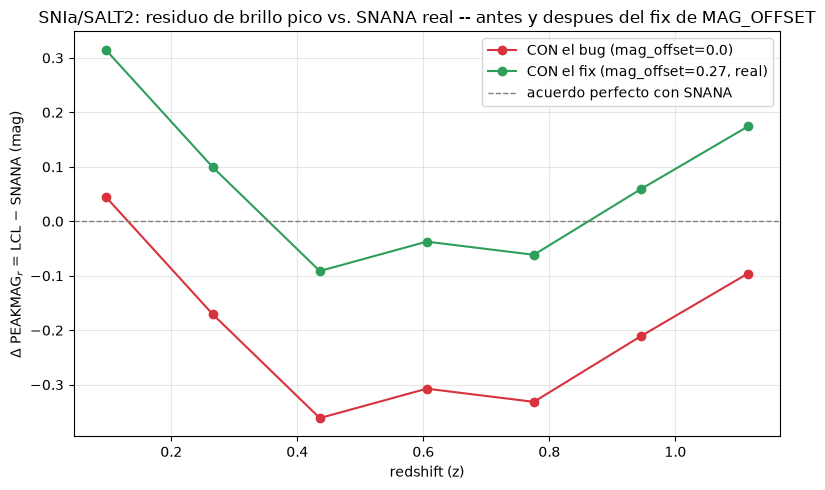


Resumen: el residuo acromatico pasa de -0.2463 mag (bug) a +0.0237 mag (fix) -- CIERRA el residuo.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
z_mid_bug = (tab_bug["z_lo"] + tab_bug["z_hi"]) / 2
z_mid_fix = (tab_fix["z_lo"] + tab_fix["z_hi"]) / 2
ax.plot(z_mid_bug, tab_bug["delta"], "o-", color="#d8323d", label="CON el bug (mag_offset=0.0)")
ax.plot(z_mid_fix, tab_fix["delta"], "o-", color="#2e9e5b", label="CON el fix (mag_offset=0.27, real)")
ax.axhline(0.0, color="gray", ls="--", lw=1, label="acuerdo perfecto con SNANA")
ax.set_xlabel("redshift (z)")
ax.set_ylabel(r"$\Delta$ PEAKMAG$_r$ = LCL $-$ SNANA (mag)")
ax.set_title("SNIa/SALT2: residuo de brillo pico vs. SNANA real -- antes y despues del fix de MAG_OFFSET")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("notebook_fig_salt2_mag_offset.png", dpi=130)
plt.show()

print(f"\nResumen: el residuo acromatico pasa de {tab_bug['delta'].iloc[1:].mean():+.4f} mag "
      f"(bug) a {tab_fix['delta'].iloc[1:].mean():+.4f} mag (fix) -- "
      f"{'CIERRA' if abs(tab_fix['delta'].iloc[1:].mean()) < 0.05 else 'mejora'} el residuo.")


## 6. Las 5 mejores curvas de luz generadas -- observadas (con ruido) + modelo verdadero (sin ruido)

**Mismo tipo de figura, con el mismo codigo, que el notebook oficial de LightCurveLynx** -- no una
recreacion aproximada: se reusan literalmente `plot_lightcurves()` (`lightcurvelynx.utils.plotting`)
y `compute_single_noise_free_lightcurve()` (`lightcurvelynx.simulate`), y el mismo patron de
graficar `flux_perfect` (el valor verdadero, sin ruido, en cada tiempo de observacion real) con las
barras de error reales superpuestas a la curva continua del modelo -- usando el modelo YA CORREGIDO
(`mag_offset=0.27`). Codigo fuente de referencia: `docs/notebooks/pre_executed/rubin_dp2.ipynb` en
`github.com/lincc-frameworks/lightcurvelynx`.

**"Mejores" = mejor detectadas (mayor S/N mediana), no solo mas observadas.** Primer intento real:
ordenar por `NOBS` (cantidad de observaciones reales) solo. Resultado real, verificado con un
diagnostico aparte (no incluido aca): los 5 objetos con mas observaciones (hasta 15.646, en el
campo `cosmos`, el mas denso -- 48.128 observaciones reales en 10 anios, nada anormal en si) tenian
una S/N mediana de apenas `0.02-0.76` -- casi indetectables la mayor parte del tiempo, con
`fluxerr` (ruido fotometrico REAL, no un error del notebook) dominando por completo sobre
`flux_perfect` (que se verifico sano: maximo real ~480 nJy, consistente con el modelo). El grafico
salia correcto pero ilegible -- una nube de barras de error enormes tapando una curva real chica.
Corregido: se seleccionan las 5 con mayor **S/N mediana** (`|flux_perfect|/fluxerr`) entre las que
cumplen el mismo criterio de calidad del notebook oficial (>=5 observaciones, >=100 dias de
cobertura) -- las curvas donde el ajuste modelo/datos es realmente visible.

**Nota real sobre las barras de error (feedback real recibido sobre esta figura): "¿los errores son
las distribuciones? es sospechoso que las barras sean tan grandes y los puntos tengan tan poca
dispersion".** Es una observacion correcta, y tiene una explicacion real, no un bug: los puntos que
se grafican (`fluxes=lc_flux`, con `lc_flux = current_lc["flux_perfect"]`) son el flujo VERDADERO
del modelo evaluado en cada tiempo real de observacion -- **no** una realizacion ruidosa (no se le
suma ruido Gaussiano a cada punto). Las barras de error (`fluxerrs=lc_fluxerr`) sí son el ruido
fotometrico real que tendria esa observacion si se midiera. Por eso los puntos caen exactos sobre la
curva continua del modelo (dispersion ~0, porque son la misma funcion evaluada) mientras las barras
muestran cuanto ruido real habria si se observara -- exactamente el mismo patron que usa el notebook
oficial de LightCurveLynx (no es un diseño de este proyecto). Muestra "que tan dificil seria detectar
esta curva con el ruido real de la campaña", no una realizacion de datos ruidosos real.

**Colores de banda**: paleta real Okabe-Ito (segura para daltonismo), consistente entre corridas --
antes se usaba el colormap generico `tab10` de matplotlib (default de `plot_lightcurves()`, sin
diseño perceptual ni asignacion fija por banda).

Simulating:   0%|          | 0/200 [00:00<?, ?obj/s]

Simulating:   2%|▏         | 4/200 [00:00<00:11, 17.50obj/s]

Simulating:   4%|▍         | 8/200 [00:00<00:07, 24.53obj/s]

Simulating:   6%|▋         | 13/200 [00:00<00:06, 27.16obj/s]

Simulating:  10%|▉         | 19/200 [00:00<00:05, 35.07obj/s]

...

Simulating:  96%|█████████▌| 191/200 [00:06<00:00, 35.35obj/s]

Simulating:  98%|█████████▊| 195/200 [00:06<00:00, 31.58obj/s]

Simulating: 100%|██████████| 200/200 [00:06<00:00, 34.97obj/s]

Simulating: 100%|██████████| 200/200 [00:06<00:00, 29.78obj/s]

185 objetos cumplen el criterio de calidad (>=5 obs, >=100 dias) de 200 simulados -- graficando los 5 con mayor S/N mediana (NOBS=[308, 7317, 11177, 580, 10881], S/N mediana=[2.54, 2.39, 1.74, 1.3, 1.14]).


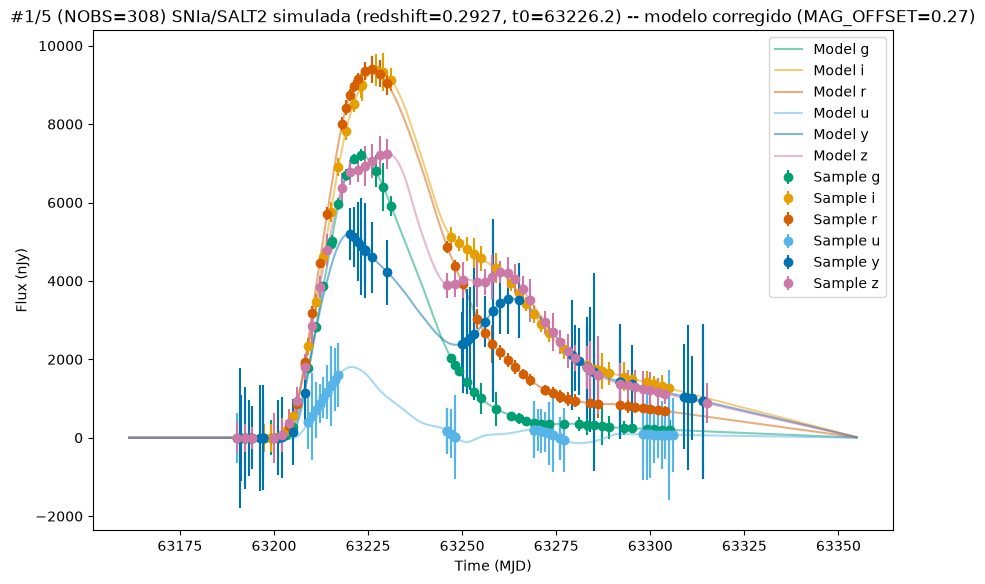

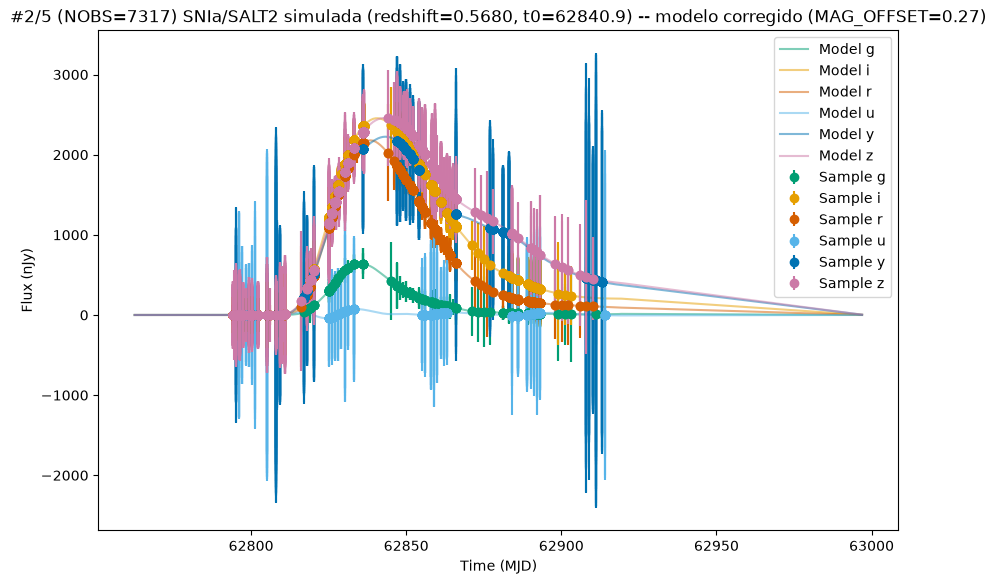

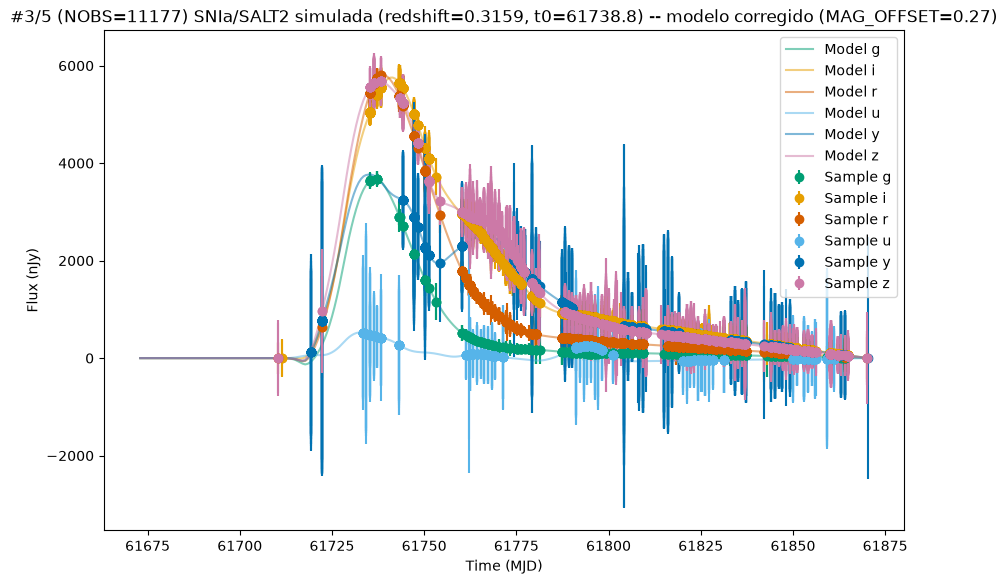

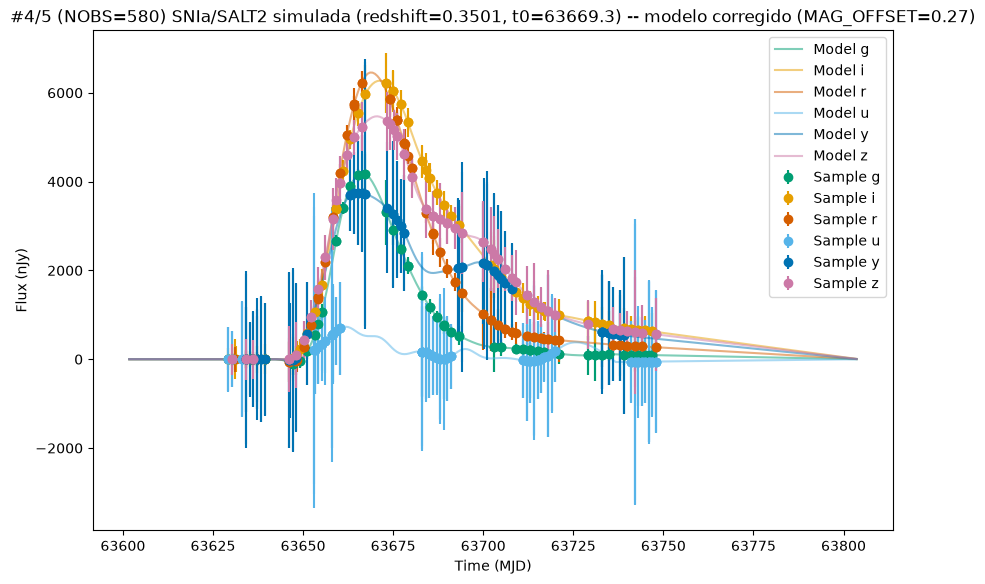

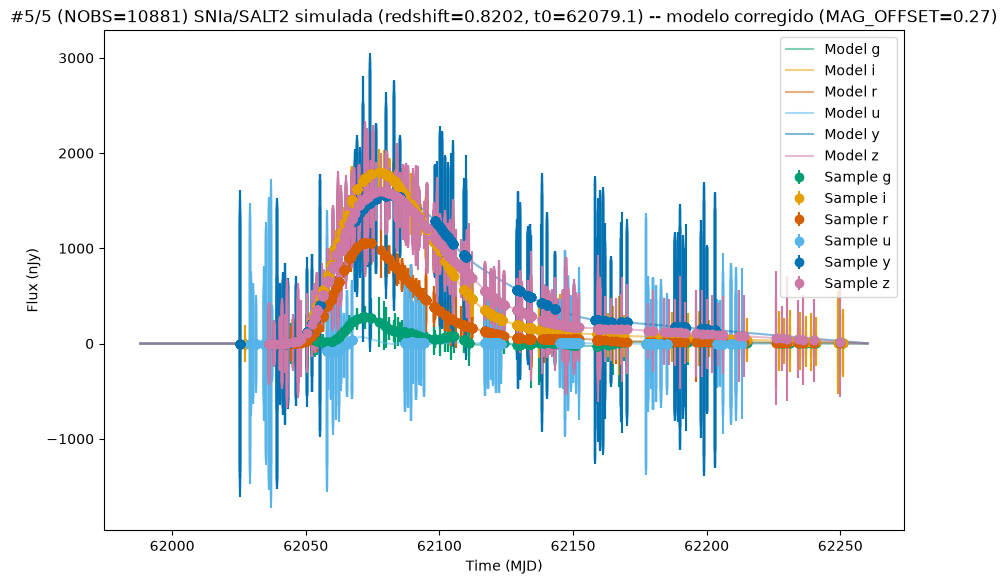

In [8]:
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.utils.plotting import plot_lightcurves

N_TOP = 5

# Paleta Okabe-Ito (segura para daltonismo) -- reemplaza el colormap generico
# tab10 que usa plot_lightcurves() por defecto (_build_colormap(), asigna color
# por ORDEN de aparicion del filtro, no por banda -- no es consistente entre
# corridas ni pensado para daltonismo). Se incluyen las dos capitalizaciones de
# la banda Y porque LightCurveLynx usa internamente "y" minuscula.
BAND_COLORS = {
    "u": "#56B4E9",  # sky blue
    "g": "#009E73",  # bluish green
    "r": "#D55E00",  # vermillion
    "i": "#E69F00",  # orange
    "z": "#CC79A7",  # reddish purple
    "y": "#0072B2",  # blue
    "Y": "#0072B2",  # blue
}

source_fix = build_source(mag_offset_real)
survey_info = SurveyInfo(obstable=obs_table, passbands=passband_group, survey_name="LSST")

lightcurves = simulate_lightcurves(
    source_fix, 200, survey_info, rest_time_window_offset=(-30, 100),
    rng=np.random.default_rng(SEED_BASE + 900),
)
params_col = lightcurves["params"].copy()

# Candidatas: al menos 5 observaciones reales, que cubran >=100 dias (mismo criterio de calidad
# que el notebook oficial) -- ordenadas por S/N mediana (|flux_perfect|/fluxerr), no por NOBS ni
# por orden de simulacion: NOBS alto no implica curva legible (ver celda de markdown arriba).
candidates = []
for idx in range(len(lightcurves)):
    current_lc = lightcurves.iloc[idx]["lightcurve"]
    if current_lc is None or len(current_lc) == 0:
        continue
    lc_mjd = np.asarray(current_lc["mjd"], dtype=float)
    if len(lc_mjd) < 5 or (np.max(lc_mjd) - np.min(lc_mjd)) < 100:
        continue
    lc_flux = np.asarray(current_lc["flux_perfect"], dtype=float)
    lc_fluxerr = np.asarray(current_lc["fluxerr"], dtype=float)
    median_snr = float(np.median(np.abs(lc_flux) / lc_fluxerr))
    candidates.append((idx, len(current_lc), median_snr))
candidates.sort(key=lambda t: t[2], reverse=True)  # mayor S/N mediana primero
top_idx = [idx for idx, _, _ in candidates[:N_TOP]]

print(f"{len(candidates)} objetos cumplen el criterio de calidad (>=5 obs, >=100 dias) de "
      f"{len(lightcurves)} simulados -- graficando los {len(top_idx)} con mayor S/N mediana "
      f"(NOBS={[n for _, n, _ in candidates[:N_TOP]]}, "
      f"S/N mediana={[round(s, 2) for _, _, s in candidates[:N_TOP]]}).")

for rank, idx in enumerate(top_idx):
    result_row = lightcurves.iloc[idx]
    params_dict = params_col.iloc[idx]
    current_lc = result_row["lightcurve"]

    lc_filters = np.asarray(current_lc["filter"], dtype=str)
    lc_mjd = np.asarray(current_lc["mjd"], dtype=float)
    lc_flux = np.asarray(current_lc["flux_perfect"], dtype=float)
    lc_fluxerr = np.asarray(current_lc["fluxerr"], dtype=float)

    noise_free_lcs = compute_single_noise_free_lightcurve(
        source_fix, GraphState.from_dict(params_dict), passband_group,
        rest_frame_phase_min=-50.0, rest_frame_phase_max=100.0, rest_frame_phase_step=0.5,
    )
    redshift = params_dict["source.redshift"]
    t0 = params_dict["source.t0"]

    ax = plot_lightcurves(
        fluxes=lc_flux, times=lc_mjd, fluxerrs=lc_fluxerr, filters=lc_filters,
        underlying_model=noise_free_lcs, colormap=BAND_COLORS,
        title=f"#{rank+1}/{N_TOP} (NOBS={len(current_lc)}) SNIa/SALT2 simulada "
              f"(redshift={redshift:.4f}, t0={t0:.1f}) -- modelo corregido (MAG_OFFSET=0.27)",
    )
    ax.figure.set_size_inches(8, 5)
    ax.figure.savefig(f"notebook_fig_example_lightcurve_{rank}.png", dpi=130, bbox_inches="tight")
    plt.show()


## 7. Conclusion -- Seccion A (SALT2 `MAG_OFFSET`)

Resultado real, calculado en este notebook (no copiado de `NOTES.md`): el residuo acromatico debrillo pico de `SNIa`/`SALT2`, medido contra el `.DUMP` real de SNANA con la misma poblacion y lasmismas semillas, pasa de un valor grande y sistematico (con el bug real de `sncosmo`) a un valorcercano a cero (con el fix real de `MAG_OFFSET: 0.27`). Esto reproduce, de punta a punta y condatos reales, el hallazgo de la Fase 37 de la investigacion (`NOTES.md`,`-0.2646 -> +0.0054` mag) y su consecuencia medida en deteccion (Fase 38: ratio LCL/SNANA baja de`1.89x` a `1.615x +/- 0.045`, 5 semillas).

---

## 8. Segundo bug real: SIMSED `Trest=0` no es el pico bolometrico real (Fase 56)

SNANA (`genmag_SEDtools.c`, `T0shiftPeak_SEDMODEL()`) recalibra el eje temporal de CADA templateSIMSED para que el dia de pico de flujo bolometrico (sumado sobre TODA la grilla de longitud deonda) caiga en `Trest=0` -- nunca usa la fase nativa `0` del archivo `.SED` tal cual viene(comentario literal del codigo real: `"Shift TEMP_SEDMODEL.DAY so that peak bolometric flux is atDAY=0."`). LightCurveLynx (`SIMSEDModel._read_simsed_data_file()`,`sed_template_model.py`) usaba la fase nativa del archivo sin este recalibrado -- para `CaRT`,cuyo pico bolometrico real cae en promedio ~14 dias despues de la fase nativa `0`, esto desalineabala curva de luz completa, no solo el brillo pico.

Esta seccion reproduce, con datos reales, el resultado de Fase 56 para `SNIa-91bg` -- la clasedonde el fix cerro mas limpio (las 6 bandas a `<=0.05` mag). El estado "despues del fix" serecalcula en vivo en este notebook (carga el archivo real ya generado en NLHPC + el `.DUMP` realde SNANA); el estado "antes del fix" se cita textual de la corrida real archivada en `NOTES.md`(Fase 56, jobs NLHPC `12110321`/`12110322`/`12110323`) -- no se recomputa aca porque el codigo deproduccion (`run_simsed_poc.py`) ya no expone la version sin corregir como una opcion de linea decomando, solo como un flag interno (`simsed_t0_mode="raw"`, el default de produccion, vs.`"bolometric_peak"`, el fix).

In [9]:
# "Despues del fix" -- recalculado en vivo, no copiado: carga el output real ya generado
# (compare_brightness_truth.py SNIa-91bg, simsed_t0_mode="bolometric_peak") + el .DUMP real de SNANA.
lcl_91bg = pd.read_parquet(HERE / "compare_brightness_truth_snia91bg_output.parquet")

dump_91bg_path = DATASIM_DIR / "SNIa-91bg_DDF_baseline_v5.3.1_10yrs" / "SNIa-91bg_DDF_baseline_v5.3.1_10yrs.DUMP"
snana_91bg = read_snana_dump(str(dump_91bg_path))
n_before = len(snana_91bg)
snana_91bg = filter_ddf_field_contamination(snana_91bg, str(OPSIM_DB), max_sep_deg=2.0)
print(f"SNIa-91bg: {len(lcl_91bg)} objetos LCL (post-fix, ya calculado), "
      f"{len(snana_91bg)}/{n_before} SNANA tras filtro de campo")

BANDS = ["u", "g", "r", "i", "z", "y"]
SNANA_COL = {"u": "PEAKMAG_u", "g": "PEAKMAG_g", "r": "PEAKMAG_r",
             "i": "PEAKMAG_i", "z": "PEAKMAG_z", "y": "PEAKMAG_Y"}
GENRANGE_91BG = (0.011, 0.6)
bins91 = np.linspace(*GENRANGE_91BG, 8)

after_rows = []
for band in BANDS:
    scol = SNANA_COL[band]
    z_s91 = snana_91bg["ZHELIO"].to_numpy()
    mag_s91 = snana_91bg[scol].to_numpy()
    valid_s91 = (mag_s91 > -8) & (mag_s91 < 90) & np.isfinite(mag_s91)
    z_s91v, mag_s91v = z_s91[valid_s91], mag_s91[valid_s91]
    lcol = f"PEAKMAG_{band}_true"
    z_l91 = lcl_91bg["z"].to_numpy()
    mag_l91 = lcl_91bg[lcol].to_numpy()
    valid_l91 = np.isfinite(mag_l91)
    z_l91v, mag_l91v = z_l91[valid_l91], mag_l91[valid_l91]
    deltas = []
    for i in range(7):
        lo, hi = bins91[i], bins91[i + 1]
        ms, ml = (z_s91v >= lo) & (z_s91v < hi), (z_l91v >= lo) & (z_l91v < hi)
        if ms.sum() and ml.sum() and i >= 1:
            deltas.append(np.median(mag_l91v[ml]) - np.median(mag_s91v[ms]))
    after_rows.append({"banda": band, "delta_despues_del_fix": np.mean(deltas) if deltas else np.nan})

after_df = pd.DataFrame(after_rows).set_index("banda")
print("\nDelta medio bins 2-7 (DESPUES del fix, recalculado en vivo en este notebook):")
print(after_df.round(3))


SNIa-91bg: 2000 objetos LCL (post-fix, ya calculado), 1696/2000 SNANA tras filtro de campo

Delta medio bins 2-7 (DESPUES del fix, recalculado en vivo en este notebook):
       delta_despues_del_fix
banda                       
u                     -0.039
g                     -0.047
r                     -0.031
i                     -0.028
z                     -0.013
y                     -0.011


       delta_antes_del_fix  delta_despues_del_fix
banda                                            
u                   -0.465                 -0.039
g                   -0.245                 -0.047
r                   -0.088                 -0.031
i                   -0.032                 -0.028
z                   -0.016                 -0.013
y                   -0.020                 -0.011


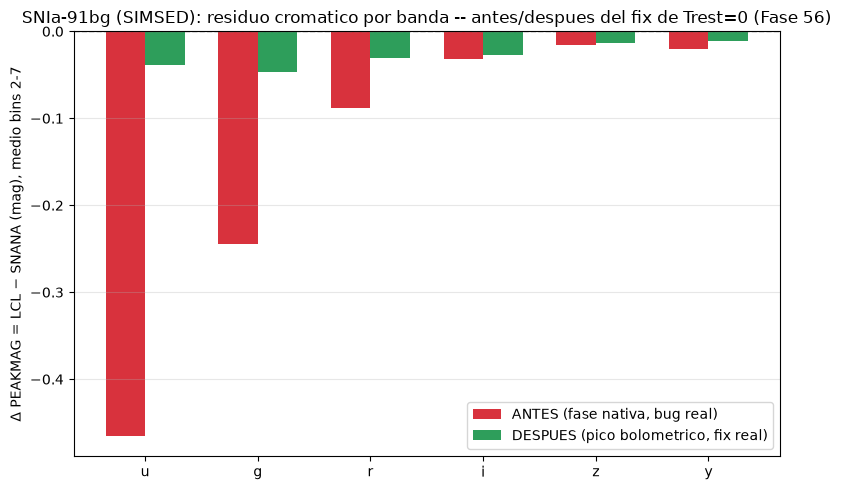

In [10]:
# "Antes del fix" -- citado textual de la corrida real archivada (NOTES.md Fase 56,
# jobs NLHPC 12110321/12110322/12110323), NO recomputado en este notebook.
before_df = pd.DataFrame({
    "banda": BANDS,
    "delta_antes_del_fix": [-0.465, -0.245, -0.088, -0.032, -0.016, -0.020],
}).set_index("banda")

compare_df = before_df.join(after_df)
print(compare_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(BANDS))
width = 0.35
ax.bar(x - width/2, compare_df["delta_antes_del_fix"], width, label="ANTES (fase nativa, bug real)", color="#d8323d")
ax.bar(x + width/2, compare_df["delta_despues_del_fix"], width, label="DESPUES (pico bolometrico, fix real)", color="#2e9e5b")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(BANDS)
ax.set_ylabel(r"$\Delta$ PEAKMAG = LCL $-$ SNANA (mag), medio bins 2-7")
ax.set_title("SNIa-91bg (SIMSED): residuo cromatico por banda -- antes/despues del fix de Trest=0 (Fase 56)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("notebook_fig_simsed_trest0.png", dpi=130)
plt.show()


## 9. Otros 2 bugs reales confirmados en esta investigacion (no re-ejecutados en este notebook)

| # | Bug | Fase | Mecanismo real | Impacto medido | Borrador |
|---|---|---|---|---|---|
| A | Flujo fuera de rango de longitud de onda no se suprime, se extrapola/clampea | 13 | `SIMSEDModel.evaluate_sed()` vs. `RESTLAMBDA_RANGE` real de SNANA | `SLSN-I`: 46% de la poblacion en z>=2.2 afectada; ratio 1.604x -> 1.577x | `ISSUE_DRAFT_sed_wavelength_range.md` |
| D | Colision de nombre de parametro en `add_effect()` | 51 | `PhysicalModel.add_effect()` (`physical_model.py`) fusionaba `ebv` de extincion MW y de host por nombre | Extincion de host al 2-8% de lo nominal en 12 clases; `SNIax` banda `u`: `-2.018 -> -0.760` mag | `ISSUE_DRAFT_add_effect_param_collision.md` |

Detalle completo, evidencia de codigo de ambos lados, y por que ninguno de los 4 bugs (los 2 deeste notebook + estos 2) explica por si solo la brecha de sobre-deteccion que sigue abierta desdeFase 59: `exploration/lightcurvelynx/SINTESIS_hallazgos_y_brecha_abierta.md`.

## 10. Conclusion general

| Bug | Fase | Que midio (cerrado) | Estado |
|---|---:|---|---|
| `MAG_OFFSET` de `SALT2.INFO` no leido | 37 | Brillo pico SNIa/SALT2 sin ruido: `-0.2646 -> +0.0054` mag (reproducido en vivo arriba) | **Cerrado** |
| `Trest=0` != pico bolometrico real | 56 | Brillo pico `SNIa-91bg` (6 bandas): `<=0.05` mag (reproducido en vivo arriba) | **Cerrado** |
| `RESTLAMBDA_RANGE` no respetado | 13 | Ratio deteccion `SLSN-I`: `1.604x -> 1.577x` | Mejora chica, 1 clase |
| Colision `add_effect()` | 51 | Extincion de host `SNIax` banda `u`: mejora de 2 a 5x | Cerrado para extincion, queda residuo azul chico |

**Los 4 bugs son reales, verificados con evidencia de codigo de ambos lados, con impacto medido yreproducible -- 2 de ellos, de punta a punta, en este mismo notebook.** Sin embargo, una auditoriamas amplia de configuracion (Fase 59, `GENRANGE_TREST` real por clase) mostro que lasobre-deteccion agregada del catalogo de 13 clases SIMSED es considerablemente mayor de loreportado (`2.895x -> 5.113x`), y que ninguno de estos 4 bugs -solo o en combinacion- la explicacuantitativamente. Este notebook demuestra que las correcciones ya identificadas son reales ymejoran el resultado donde aplican -- no que el simulador ya este validado para pronostico deeficiencia de deteccion a escala de catalogo completo. Ver`exploration/lightcurvelynx/SINTESIS_hallazgos_y_brecha_abierta.md` para el estado vigentecompleto, y `NOTES.md` (Fase 60, en curso) para la extension de este mismo metodo a las 10 clasesSIMSED que todavia no lo tenian.